# 04 — Commit Activity by Hour: Histogram

## What this notebook does

Visualizes the distribution of commit activity across hours of the day,
comparing working days and weekends on a single overlapping histogram.

## Data

- **Source:** `checking-logs.sqlite` → table `checker`
- **Filtered:** only real students (`uid LIKE 'user_%'`)
- **No aggregation:** raw hour extracted from each individual commit timestamp

## Key steps

1. Query checker timestamps via SQL
2. Extract hour and day of week from timestamp
3. Label each record as `working_day` or `weekend`
4. Split into two separate Series by day type
5. Plot overlapping histograms with 24 bins (one per hour), using transparency (`alpha`) to show both distributions simultaneously

## Result

An overlapping histogram showing when students tend to commit during
working days vs weekends. Working day activity peaks around **11:00, 13:00,
22:00 and 23:00**, suggesting students work both during lunch breaks and
late at night. Weekend activity is more spread out.

## Tools

`pandas` · `sqlite3` · `matplotlib`

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
df = pd.io.sql.read_sql("""
                        SELECT c.timestamp
                        FROM checker AS c
                        WHERE c.uid LIKE 'user_%' 
                        """,
                        conn,
                        parse_dates=['timestamp'])
df.dtypes

timestamp    datetime64[us]
dtype: object

In [4]:
day_of_week = df['timestamp'].dt.day_of_week
hour = df['timestamp'].dt.hour

day_of_week = day_of_week.apply(lambda x: 'working_day' if x < 5 else 'weekend')
new_df = pd.DataFrame({'day_of_week': day_of_week, 'hour': hour})
new_df.head()


,day_of_week,hour
0,working_day,5
1,working_day,5
2,working_day,5
3,working_day,5
4,working_day,5


In [9]:
working_day_hours = new_df[new_df['day_of_week'] == 'working_day']
working_day_hours_Series = working_day_hours['hour']
print(working_day_hours)

weekend_hours = new_df[new_df['day_of_week'] == 'weekend']
weekend_hours_Series = weekend_hours['hour']
print(weekend_hours)

      day_of_week  hour
0     working_day     5
1     working_day     5
2     working_day     5
3     working_day     5
4     working_day     5
...           ...   ...
3202  working_day    20
3203  working_day    20
3204  working_day    20
3205  working_day    20
3206  working_day    20

[2037 rows x 2 columns]
     day_of_week  hour
23       weekend     7
24       weekend    13
25       weekend    13
26       weekend    13
27       weekend    13
...          ...   ...
3088     weekend    22
3089     weekend    22
3090     weekend    22
3091     weekend    22
3092     weekend    22

[1170 rows x 2 columns]


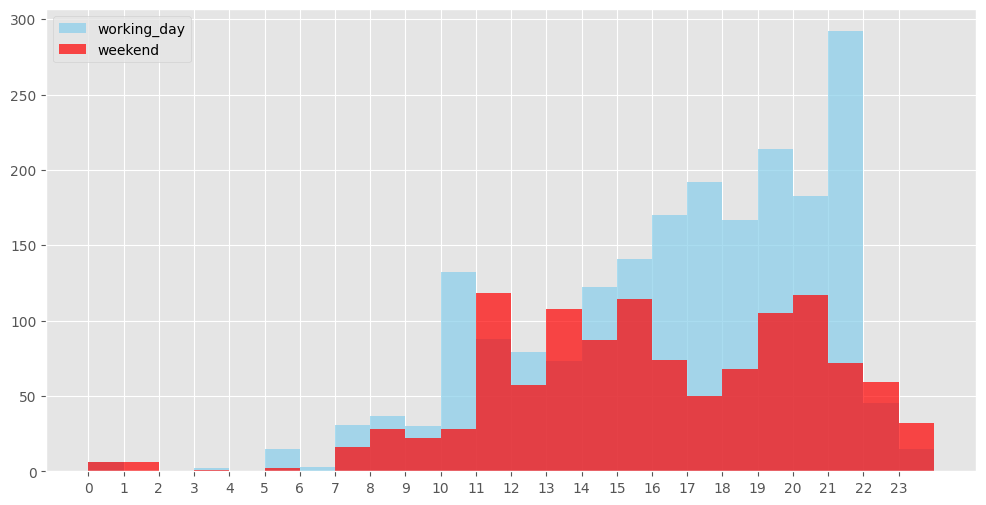

In [6]:

plt.style.use('ggplot')
plt.figure(figsize=(12, 6))
plt.hist(working_day_hours_Series, bins=24, range=(0, 24), color='skyblue', alpha=0.7, label='working_day')
plt.hist(weekend_hours_Series, bins=24, range=(0, 24), color='red', alpha=0.7, label='weekend')
plt.legend()
plt.xticks(range(24))
plt.show()

In [7]:
conn.close()